In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Set styling for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# PART 1: LOAD AND EXAMINE DATA

In [2]:
# Load the dataset

try:
    df = pd.read_csv('https://raw.githubusercontent.com/iamctodd/datasets/refs/heads/main/ecommerce_data.csv')
    print("Data loaded successfully!")
except:
    print("Error: Unable to load the dataset")
    # For workshop purposes, we could create a simulated dataset here
    # But we'll assume participants have access to the actual data file



Data loaded successfully!


In [3]:
df.shape

(350, 11)

In [ ]:
# YOUR CODE: Initial data exploration
# Display basic information about the dataset


In [ ]:
# prompt: describe df

# Display basic information about the dataset
print(df.info())

# Display the first few rows
print(df.head())

# Display descriptive statistics
print(df.describe())

# Check for missing values
print(df.isnull().sum())

# Get the column names and their data types
print(df.dtypes)

# Get the shape of the DataFrame (number of rows and columns)
print(df.shape)

# Get unique values and their counts for categorical columns (example for 'Country')
if 'Country' in df.columns:
    print(df['Country'].value_counts())

# Get unique values in a specific column (example for 'CustomerID')
if 'CustomerID' in df.columns:
    print(df['CustomerID'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB
None
   Customer ID  Gender  Age           City Membership Type  Total Spend  \
0          101  Female   29 

# PART 2: SAMPLING TECHNIQUES

In [ ]:
# Define sample size
sample_size = min(100, len(df))
print(f"Using sample size of {sample_size} records")



Using sample size of 100 records


### 1. Simple Random Sampling

In [ ]:
# prompt: create random sample of 100 records from data

# Simple random sampling without replacement
simple_random_sample = df.sample(n=sample_size, replace=False, random_state=42) # random_state for reproducibility
print("\n--- Simple Random Sample (first 5 rows) ---")
print(simple_random_sample.head())
print(f"Shape of simple random sample: {simple_random_sample.shape}")


--- Simple Random Sample (first 5 rows) ---
     Customer ID  Gender  Age         City Membership Type  Total Spend  \
157          258    Male   35  Los Angeles          Silver       810.90   
341          442  Female   31     New York            Gold      1140.60   
315          416    Male   27        Miami          Silver       710.40   
234          335    Male   33  Los Angeles          Silver       830.75   
155          256  Female   37      Houston          Bronze       430.80   

     Items Purchased  Average Rating  Discount Applied  \
157               12             4.3             False   
341               15             4.5              True   
315               13             4.1              True   
234               13             4.2             False   
155                7             3.4             False   

     Days Since Last Purchase Satisfaction Level  
157                        13            Neutral  
341                        36          Satisfied  
31

In [ ]:
# prompt: describe

print("\n--- Descriptive Statistics of Simple Random Sample ---")
print(simple_random_sample.describe())


--- Descriptive Statistics of Simple Random Sample ---
       Customer ID         Age  Total Spend  Items Purchased  Average Rating  \
count   100.000000  100.000000   100.000000       100.000000      100.000000   
mean    272.090000   33.140000   873.616000        12.740000        4.033000   
std     104.853057    4.264062   369.434674         4.253626        0.607205   
min     104.000000   26.000000   420.800000         7.000000        3.000000   
25%     177.750000   30.000000   503.125000         9.750000        3.400000   
50%     275.500000   32.000000   795.200000        12.000000        4.100000   
75%     365.500000   36.000000  1183.300000        16.000000        4.525000   
max     447.000000   43.000000  1520.100000        21.000000        4.900000   

       Days Since Last Purchase  
count                100.000000  
mean                  24.240000  
std                   12.547381  
min                    9.000000  
25%                   14.750000  
50%                

### 2. Stratified Sampling

In [ ]:
# prompt: create a stratified sample based on membership type

# Stratified sampling based on 'Membership Type'
if 'Membership Type' in df.columns:
    # Calculate the proportion of each 'Membership Type'
    stratified_sample = df.groupby('Membership Type', group_keys=False).apply(lambda x: x.sample(frac=sample_size/len(df), random_state=42))
    print("\n--- Stratified Sample (first 5 rows) ---")
    print(stratified_sample.head())
    print(f"Shape of stratified sample: {stratified_sample.shape}")

    print("\n--- Distribution of 'Membership Type' in Original Data ---")
    print(df['Membership Type'].value_counts(normalize=True))

    print("\n--- Distribution of 'Membership Type' in Stratified Sample ---")
    print(stratified_sample['Membership Type'].value_counts(normalize=True))
else:
    print("\n'Membership Type' column not found in the DataFrame. Cannot perform stratified sampling.")


--- Stratified Sample (first 5 rows) ---
     Customer ID  Gender  Age     City Membership Type  Total Spend  \
253          354  Female   43  Chicago          Bronze       510.75   
14           115  Female   42  Chicago          Bronze       530.40   
128          229  Female   43  Chicago          Bronze       500.75   
122          223  Female   42  Chicago          Bronze       520.40   
32           133  Female   42  Chicago          Bronze       520.40   

     Items Purchased  Average Rating  Discount Applied  \
253               10             3.3              True   
14                 9             3.5              True   
128               10             3.3              True   
122                9             3.5              True   
32                 9             3.5              True   

     Days Since Last Purchase Satisfaction Level  
253                        41        Unsatisfied  
14                         38        Unsatisfied  
128                        40

### 3. Systematic Sampling

In [ ]:
# prompt: make a systematic sample of 100

# Ensure the sample size does not exceed the total number of rows
n = min(100, len(df))

# Calculate the interval (k)
k = len(df) // n

# Select a random starting point between 0 and k-1
start_index = random.randint(0, k - 1)

# Create the indices for the systematic sample
systematic_indices = list(range(start_index, len(df), k))

# Extract the systematic sample using the generated indices
systematic_sample = df.iloc[systematic_indices].reset_index(drop=True)

print("\n--- Systematic Sample (first 5 rows) ---")
print(systematic_sample.head())
print(f"Shape of systematic sample: {systematic_sample.shape}")

print("\n--- Descriptive Statistics of Systematic Sample ---")
print(systematic_sample.describe())


--- Systematic Sample (first 5 rows) ---
   Customer ID Gender  Age         City Membership Type  Total Spend  \
0          102   Male   34  Los Angeles          Silver       780.50   
1          105   Male   27        Miami          Silver       720.40   
2          108   Male   35  Los Angeles          Silver       800.90   
3          111   Male   32        Miami          Silver       690.30   
4          114   Male   33  Los Angeles          Silver       820.75   

   Items Purchased  Average Rating  Discount Applied  \
0               11             4.1             False   
1               13             4.0              True   
2               12             4.2             False   
3               11             3.8              True   
4               13             4.4             False   

   Days Since Last Purchase Satisfaction Level  
0                        18            Neutral  
1                        55        Unsatisfied  
2                        14            Ne

### 4. Cluster Sampling

In [ ]:
# prompt: make a cluster sample of 100 based on membership type

# Ensure the sample size does not exceed the total number of rows
n = min(100, len(df))

# Check if 'Membership Type' column exists
if 'Membership Type' in df.columns:
    # Get unique clusters (Membership Types)
    clusters = df['Membership Type'].unique()
    num_clusters = len(clusters)

    if num_clusters == 0:
        print("\nNo 'Membership Type' clusters found for cluster sampling.")
    else:
        # Decide how many clusters to sample
        # A simple approach: sample a fraction of clusters. Adjust as needed.
        # Here, let's try to get roughly n records by sampling clusters.
        # This is a simplified cluster sampling; a more robust method might consider cluster sizes.

        # Calculate the average size of a cluster
        avg_cluster_size = len(df) / num_clusters

        # Estimate the number of clusters to sample to get approximately n records
        num_clusters_to_sample = max(1, int(n / avg_cluster_size))
        num_clusters_to_sample = min(num_clusters_to_sample, num_clusters) # Ensure we don't sample more clusters than exist

        print(f"\nSampling {num_clusters_to_sample} out of {num_clusters} 'Membership Type' clusters.")

        # Randomly select clusters
        sampled_clusters = random.sample(list(clusters), num_clusters_to_sample)

        # Filter the DataFrame to include only rows from the sampled clusters
        cluster_sample = df[df['Membership Type'].isin(sampled_clusters)]

        print("\n--- Cluster Sample (first 5 rows) ---")
        print(cluster_sample.head())
        print(f"Shape of cluster sample: {cluster_sample.shape}")
        print(f"Number of sampled clusters: {len(cluster_sample['Membership Type'].unique())}")


        print("\n--- Distribution of 'Membership Type' in Original Data ---")
        print(df['Membership Type'].value_counts(normalize=True))

        print("\n--- Distribution of 'Membership Type' in Cluster Sample ---")
        print(cluster_sample['Membership Type'].value_counts(normalize=True))

# prompt: make a cluster sample of 100 based on membership type

import pandas as pd
import numpy as np
import random

# Assuming 'df' is your pandas DataFrame

# Ensure the sample size does not exceed the total number of rows
n = min(100, len(df))

# Check if 'Membership Type' column exists
if 'Membership Type' in df.columns:
    # Get unique clusters (Membership Types)
    clusters = df['Membership Type'].unique()
    num_clusters = len(clusters)

    if num_clusters == 0:
        print("\nNo 'Membership Type' clusters found for cluster sampling.")
    else:
        # Decide how many clusters to sample
        # A simple approach: sample a fraction of clusters. Adjust as needed.
        # Here, let's try to get roughly n records by sampling clusters.
        # This is a simplified cluster sampling; a more robust method might consider cluster sizes.

        # Calculate the average size of a cluster
        avg_cluster_size = len(df) / num_clusters

        # Estimate the number of clusters to sample to get approximately n records
        num_clusters_to_sample = max(1, int(n / avg_cluster_size))
        num_clusters_to_sample = min(num_clusters_to_sample, num_clusters) # Ensure we don't sample more clusters than exist

        print(f"\nSampling {num_clusters_to_sample} out of {num_clusters} 'Membership Type' clusters.")

        # Randomly select clusters
        sampled_clusters = random.sample(list(clusters), num_clusters_to_sample)

        # Filter the DataFrame to include only rows from the sampled clusters
        cluster_sample = df[df['Membership Type'].isin(sampled_clusters)]

        print("\n--- Cluster Sample (first 5 rows) ---")
        print(cluster_sample.head())
        print(f"Shape of cluster sample: {cluster_sample.shape}")
        print(f"Number of sampled clusters: {len(cluster_sample['Membership Type'].unique())}")


        print("\n--- Distribution of 'Membership Type' in Original Data ---")
        print(df['Membership Type'].value_counts(normalize=True))

        print("\n--- Distribution of 'Membership Type' in Cluster Sample ---")
        print(cluster_sample['Membership Type'].value_counts(normalize=True))

else:
    print("\n'Membership Type' column not found in the DataFrame. Cannot perform cluster sampling.")


Sampling 1 out of 3 'Membership Type' clusters.

--- Cluster Sample (first 5 rows) ---
    Customer ID  Gender  Age     City Membership Type  Total Spend  \
2           103  Female   43  Chicago          Bronze       510.75   
5           106  Female   37  Houston          Bronze       440.80   
8           109  Female   41  Chicago          Bronze       495.25   
11          112  Female   36  Houston          Bronze       470.50   
14          115  Female   42  Chicago          Bronze       530.40   

    Items Purchased  Average Rating  Discount Applied  \
2                 9             3.4              True   
5                 8             3.1             False   
8                10             3.6              True   
11                7             3.2             False   
14                9             3.5              True   

    Days Since Last Purchase Satisfaction Level  
2                         42        Unsatisfied  
5                         22            Neutral 

### 5. Weighted Sampling

In [ ]:
# prompt: make a weighted sample by total spend

# Weighted sampling based on 'Total Spend'
if 'Total Spend' in df.columns:
  # Calculate the probability of selecting each row based on 'Total Spend'
  # Adding a small constant to avoid zero probabilities for rows with zero spend
  df['sampling_weight'] = df['Total Spend'] + 0.001
  # Normalize the weights so they sum to 1
  df['sampling_weight'] = df['sampling_weight'] / df['sampling_weight'].sum()

  weighted_sample = df.sample(n=sample_size, replace=False, weights='sampling_weight', random_state=42)

  print("\n--- Weighted Sample (first 5 rows) ---")
  print(weighted_sample.head())
  print(f"Shape of weighted sample: {weighted_sample.shape}")

  print("\n--- Descriptive Statistics of Weighted Sample ---")
  print(weighted_sample.describe())

  # Clean up the temporary weight column
  df = df.drop(columns=['sampling_weight'])
else:
  print("\n'Total Spend' column not found in the DataFrame. Cannot perform weighted sampling.")


--- Weighted Sample (first 5 rows) ---
     Customer ID  Gender  Age           City Membership Type  Total Spend  \
130          231    Male   27          Miami          Silver        700.4   
332          433    Male   28  San Francisco            Gold       1490.1   
255          356    Male   27          Miami          Silver        700.4   
209          310  Female   32       New York            Gold       1170.3   
54           155  Female   31       New York            Gold       1140.6   

     Items Purchased  Average Rating  Discount Applied  \
130               13             4.0              True   
332               21             4.9             False   
255               13             4.1              True   
209               14             4.5              True   
54                15             4.6              True   

     Days Since Last Purchase Satisfaction Level  sampling_weight  
130                        53        Unsatisfied         0.002367  
332         

# PART 3: EXPLORATION

# PART 4: EXERCISES

## Exercise 1: Sampling Strategy Comparison

1. Compare the different sampling approaches applied to the e-commerce dataset:
   - Simple Random Sampling
   - Stratified Sampling (by Membership Type)
   - Systematic Sampling
   - Cluster-Based Sampling
   - Weighted Sampling (by Total Spend)
   
2. For each approach, evaluate:
   - How representative is the sample of the original data?
   - Which key metrics (e.g., average spend, age distribution) are preserved?
   - What are the pros and cons of each approach for this specific dataset?
   
3. Recommend the best sampling approach for these business questions:
   - Analyzing spending patterns across different demographics
   - Understanding factors influencing customer satisfaction
   - Identifying high-value customer segments
   - Investigating the relationship between ratings and purchases

In [ ]:
# YOUR CODE HERE

## 1. Compare the different sampling approaches applied to the e-commerce dataset:

In [ ]:
# prompt: Compare the different sampling approaches applied to the e-commerce dataset:
# Simple Random Sampling
# Stratified Sampling (by Membership Type)
# Systematic Sampling
# Cluster-Based Sampling
# Weighted Sampling (by Total Spend)

print("\n" + "="*50)
print("PART 4: EXERCISE 1 - SAMPLING STRATEGY COMPARISON")
print("="*50 + "\n")

# Helper function to compare a metric between original and sample
def compare_metric(original_df, sample_df, column, metric_name):
    if column not in original_df.columns or column not in sample_df.columns:
        print(f"  Warning: Column '{column}' not found in one or both dataframes.")
        return

    if original_df[column].dtype in ['int64', 'float64']:
        original_metric = original_df[column].agg(metric_name)
        sample_metric = sample_df[column].agg(metric_name)
        print(f"  - {metric_name} of '{column}': Original = {original_metric:.2f}, Sample = {sample_metric:.2f}")
    elif original_df[column].dtype == 'object' or original_df[column].dtype == 'category':
         print(f"  - Distribution of '{column}':")
         print("    Original:")
         print(original_df[column].value_counts(normalize=True).round(2))
         print("    Sample:")
         print(sample_df[column].value_counts(normalize=True).round(2))
    else:
        print(f"  - Cannot compare metric '{metric_name}' for column '{column}' with dtype {original_df[column].dtype}")


# Define key metrics to compare
metrics_to_compare = {
    'Total Spend': ['mean', 'median', 'std'],
    'Age': ['mean', 'median', 'std'],
    'Items Purchased': ['mean', 'median', 'std'],
    'Membership Type': ['distribution'],
    'Satisfaction Level': ['distribution'],
    'Discount Applied': ['distribution']
}


print("\n--- Comparison of Sampling Approaches ---")

# 1. Simple Random Sampling Comparison
print("\n### 1. Simple Random Sampling")
print(f"Sample Size: {simple_random_sample.shape[0]}")
for col, metrics in metrics_to_compare.items():
    for metric in metrics:
        if metric == 'distribution':
             compare_metric(df, simple_random_sample, col, 'distribution')
        else:
            compare_metric(df, simple_random_sample, col, metric)

print("\n**Pros:**")
print("- Simplest to implement.")
print("- Theoretical foundation allows for easy estimation of sampling error.")
print("- Less susceptible to human bias.")
print("\n**Cons:**")
print("- May not be representative if key subgroups are under or over-represented by chance, especially with small sample sizes.")
print("- Can be inefficient if data has natural clusters or strata.")


# 2. Stratified Sampling Comparison
if 'Membership Type' in df.columns and 'stratified_sample' in locals():
    print("\n### 2. Stratified Sampling (by Membership Type)")
    print(f"Sample Size: {stratified_sample.shape[0]}")
    for col, metrics in metrics_to_compare.items():
        for metric in metrics:
            if metric == 'distribution':
                 compare_metric(df, stratified_sample, col, 'distribution')
            else:
                compare_metric(df, stratified_sample, col, metric)

    print("\n**Pros:**")
    print(f"- Guarantees proportional representation of 'Membership Type' in the sample.")
    print("- Often more representative of the population than SRS, especially for the stratification variable.")
    print("- Can provide more precise estimates for stratum-specific analysis.")
    print("\n**Cons:**")
    print("- Requires prior knowledge of the stratification variable distribution.")
    print("- Can be more complex to implement.")
else:
    print("\n### 2. Stratified Sampling (by Membership Type)")
    print("Skipped: 'Membership Type' column or sample not available.")


# 3. Systematic Sampling Comparison
print("\n### 3. Systematic Sampling")
print(f"Sample Size: {systematic_sample.shape[0]}")
for col, metrics in metrics_to_compare.items():
    for metric in metrics:
        if metric == 'distribution':
             compare_metric(df, systematic_sample, col, 'distribution')
        else:
            compare_metric(df, systematic_sample, col, metric)

print("\n**Pros:**")
print("- Relatively simple to implement after calculating the interval.")
print("- Often provides a more evenly spread sample across the list than SRS.")
print("- Can be more efficient than SRS, especially for large populations.")
print("\n**Cons:**")
print("- Susceptible to bias if there is a hidden pattern or periodicity in the list that aligns with the sampling interval (k).")
print("- Does not guarantee representation of specific subgroups like stratified sampling.")


# 4. Cluster Sampling Comparison
if 'Membership Type' in df.columns and 'cluster_sample' in locals() and cluster_sample is not None:
    print("\n### 4. Cluster-Based Sampling (Clusters = Membership Type)")
    print(f"Sample Size: {cluster_sample.shape[0]}")
    for col, metrics in metrics_to_compare.items():
        for metric in metrics:
            if metric == 'distribution':
                 compare_metric(df, cluster_sample, col, 'distribution')
            else:
                compare_metric(df, cluster_sample, col, metric)
    print(f"  - Number of unique 'Membership Type' clusters in sample: {len(cluster_sample['Membership Type'].unique())}")
    print(f"  - Sampled clusters: {cluster_sample['Membership Type'].unique().tolist()}")


    print("\n**Pros:**")
    print(f"- Can be more cost-effective and logistically feasible if data is naturally grouped (e.g., by city, store, or in this case, potentially Membership Type if it represents a 'group').")
    print("- Doesn't require a sampling frame of individual elements, only of clusters.")
    print("\n**Cons:**")
    print("- Less precise than SRS or stratified sampling for the same sample size, as units within a cluster tend to be similar.")
    print("- Requires careful consideration of cluster definition and number of clusters to sample.")
    print("- In this specific implementation using 'Membership Type' as clusters, the sample size is highly variable and depends on the size of the randomly selected clusters.")
else:
    print("\n### 4. Cluster-Based Sampling (Clusters = Membership Type)")
    print("Skipped: 'Membership Type' column or sample not available.")


# 5. Weighted Sampling Comparison
if 'Total Spend' in df.columns and 'weighted_sample' in locals():
    print("\n### 5. Weighted Sampling (by Total Spend)")
    print(f"Sample Size: {weighted_sample.shape[0]}")
    for col, metrics in metrics_to_compare.items():
        for metric in metrics:
            if metric == 'distribution':
                 compare_metric(df, weighted_sample, col, 'distribution')
            else:
                compare_metric(df, weighted_sample, col, metric)

    print("\n**Pros:**")
    print("- Gives higher probability of selection to units with higher values of the weighting variable (e.g., 'Total Spend').")
    print("- Useful when focusing on characteristics of high-value elements.")
    print("- Can lead to more precise estimates for metrics related to the weighting variable.")
    print("\n**Cons:**")
    print("- Introduces bias if the weighting variable is not relevant to the analysis.")
    print("- Requires knowing or estimating the weighting variable for all units in the population.")
    print("- Analysis of the sample requires using inverse probability weights to account for the unequal selection probabilities.")
else:
     print("\n### 5. Weighted Sampling (by Total Spend)")
     print("Skipped: 'Total Spend' column or sample not available.")


print("\n--- Recommendations for Business Questions ---")

# 1. Analyzing spending patterns across different demographics (Age, Gender, City)
print("\n1. Analyzing spending patterns across different demographics:")
print("   - **Recommended:** Stratified Sampling (if stratifying by demographics) or Simple Random Sampling with large enough size.")
print("   - **Reasoning:** Stratified sampling ensures adequate representation of each demographic group, which is crucial for comparing spending patterns between groups. SRS is a reasonable alternative if no specific strata are prioritized, but might require a larger sample size to ensure sufficient representation of smaller demographic groups.")

# 2. Understanding factors influencing customer satisfaction
print("\n2. Understanding factors influencing customer satisfaction:")
print("   - **Recommended:** Stratified Sampling (by 'Satisfaction Level') or Simple Random Sampling.")
print("   - **Reasoning:** If you want to analyze factors distinguishing different satisfaction levels, stratifying by 'Satisfaction Level' ensures you have sufficient data points from each level (e.g., highly satisfied, neutral, dissatisfied). SRS is also viable, assuming satisfaction levels are adequately represented in the population.")

# 3. Identifying high-value customer segments
print("\n3. Identifying high-value customer segments:")
print("   - **Recommended:** Weighted Sampling (by 'Total Spend') or Stratified Sampling (if stratifying by 'Total Spend' categories - e.g., low, medium, high).")
print("   - **Reasoning:** Weighted sampling directly oversamples high-spending customers, making it very efficient for studying their characteristics. Stratified sampling based on spend categories achieves a similar goal by ensuring representation from each spend tier.")

# 4. Investigating the relationship between ratings and purchases
print("\n4. Investigating the relationship between ratings and purchases:")
print("   - **Recommended:** Simple Random Sampling.")
print("   - **Reasoning:** A simple random sample is generally sufficient for exploring the overall relationship between two variables across the entire population, assuming the relationship is not heavily skewed towards specific, undersampled subgroups.")



PART 4: EXERCISE 1 - SAMPLING STRATEGY COMPARISON


--- Comparison of Sampling Approaches ---

### 1. Simple Random Sampling
Sample Size: 100
  - mean of 'Total Spend': Original = 845.38, Sample = 873.62
  - median of 'Total Spend': Original = 775.20, Sample = 795.20
  - std of 'Total Spend': Original = 362.06, Sample = 369.43
  - mean of 'Age': Original = 33.60, Sample = 33.14
  - median of 'Age': Original = 32.50, Sample = 32.00
  - std of 'Age': Original = 4.87, Sample = 4.26
  - mean of 'Items Purchased': Original = 12.60, Sample = 12.74
  - median of 'Items Purchased': Original = 12.00, Sample = 12.00
  - std of 'Items Purchased': Original = 4.16, Sample = 4.25
  - Distribution of 'Membership Type':
    Original:
Membership Type
Gold      0.33
Silver    0.33
Bronze    0.33
Name: proportion, dtype: float64
    Sample:
Membership Type
Gold      0.38
Silver    0.32
Bronze    0.30
Name: proportion, dtype: float64
  - Distribution of 'Satisfaction Level':
    Original:
Satisfaction Le

## 2. For each approach, evaluate:

How representative is the sample of the original data?
Which key metrics (e.g., average spend, age distribution) are preserved?
What are the pros and cons of each approach for this specific dataset?

In [ ]:
# prompt: For each approach, evaluate:
# How representative is the sample of the original data?
# Which key metrics (e.g., average spend, age distribution) are preserved?
# What are the pros and cons of each approach for this specific dataset?

# Helper function to compare a metric between original and sample
def compare_metric(original_df, sample_df, column, metric_name):
    if column not in original_df.columns or column not in sample_df.columns:
        print(f"  Warning: Column '{column}' not in one or both dataframes.")
        return

    if original_df[column].dtype in ['int64', 'float64']:
        original_metric = original_df[column].agg(metric_name)
        sample_metric = sample_df[column].agg(metric_name)
        print(f"  - {metric_name} of '{column}': Original = {original_metric:.2f}, Sample = {sample_metric:.2f}")
    elif original_df[column].dtype == 'object' or original_df[column].dtype == 'category':
         print(f"  - Distribution of '{column}':")
         print("    Original:")
         print(original_df[column].value_counts(normalize=True).round(2))
         print("    Sample:")
         print(sample_df[column].value_counts(normalize=True).round(2))
    else:
        print(f"  - Cannot compare metric '{metric_name}' for column '{column}' with dtype {original_df[column].dtype}")


# Define key metrics to compare
metrics_to_compare = {
    'Total Spend': ['mean', 'median', 'std'],
    'Age': ['mean', 'median', 'std'],
    'Items Purchased': ['mean', 'median', 'std'],
    'Membership Type': ['distribution'],
    'Satisfaction Level': ['distribution'],
    'Discount Applied': ['distribution']
}


print("\n--- Comparison of Sampling Approaches ---")

# 1. Simple Random Sampling Comparison
print("\n### 1. Simple Random Sampling")
if 'simple_random_sample' in locals():
    print(f"Sample Size: {simple_random_sample.shape[0]}")
    print("\n**Representativeness:**")
    print("- Aims to be representative of the overall population on average, but may not perfectly reflect proportions of subgroups in any single sample, especially for small sample sizes.")
    print("\n**Metrics Preserved:**")
    for col, metrics in metrics_to_compare.items():
        for metric in metrics:
            if metric == 'distribution':
                 compare_metric(df, simple_random_sample, col, 'distribution')
            else:
                compare_metric(df, simple_random_sample, col, metric)

    print("\n**Pros & Cons for this dataset:**")
    print("  **Pros:**")
    print("  - Easiest to implement.")
    print("  - Good baseline for comparison.")
    print("  **Cons:**")
    print("  - Might under-represent less common 'Membership Types' or specific age/spend brackets if the sample size is small.")
    print("  - Variability in metric preservation depending on the random seed and sample size.")
else:
    print("Simple random sample not available.")


# 2. Stratified Sampling Comparison
if 'Membership Type' in df.columns and 'stratified_sample' in locals() and stratified_sample is not None:
    print("\n### 2. Stratified Sampling (by Membership Type)")
    print(f"Sample Size: {stratified_sample.shape[0]}")
    print("\n**Representativeness:**")
    print(f"- Highly representative of the original data specifically with respect to the distribution of 'Membership Type'. Other characteristics are randomly sampled within strata.")
    print("\n**Metrics Preserved:**")
    for col, metrics in metrics_to_compare.items():
        for metric in metrics:
            if metric == 'distribution':
                 compare_metric(df, stratified_sample, col, 'distribution')
            else:
                compare_metric(df, stratified_sample, col, metric)

    print("\n**Pros & Cons for this dataset:**")
    print("  **Pros:**")
    print(f"  - Guarantees proportional representation of 'Membership Type', crucial for analyses focusing on this variable.")
    print("  - Can improve precision of estimates if 'Membership Type' is correlated with variables of interest (like 'Total Spend').")
    print("  **Cons:**")
    print("  - Requires the 'Membership Type' column to exist and be accurate.")
    print("  - Slightly more complex to implement than SRS.")
else:
    print("\n### 2. Stratified Sampling (by Membership Type)")
    print("Skipped: 'Membership Type' column or stratified sample not available.")


# 3. Systematic Sampling Comparison
print("\n### 3. Systematic Sampling")
if 'systematic_sample' in locals():
    print(f"Sample Size: {systematic_sample.shape[0]}")
    print("\n**Representativeness:**")
    print("- Can be representative if the underlying data has no hidden patterns aligning with the sampling interval. Provides a relatively even spread across the dataset's original index.")
    print("\n**Metrics Preserved:**")
    for col, metrics in metrics_to_compare.items():
        for metric in metrics:
            if metric == 'distribution':
                 compare_metric(df, systematic_sample, col, 'distribution')
            else:
                compare_metric(df, systematic_sample, col, metric)

    print("\n**Pros & Cons for this dataset:**")
    print("  **Pros:**")
    print("  - Relatively simple to implement.")
    print("  - Can be more efficient for large ordered datasets.")
    print("  **Cons:**")
    print("  - Susceptible to bias if the dataset has a cyclical pattern related to the order (unlikely in this e-commerce data unless it's time-ordered).")
    print("  - Doesn't explicitly ensure representation of specific subgroups.")
else:
    print("Systematic sample not available.")

# 4. Cluster Sampling Comparison
if 'Membership Type' in df.columns and 'cluster_sample' in locals() and cluster_sample is not None:
    print("\n### 4. Cluster-Based Sampling (Clusters = Membership Type)")
    print(f"Sample Size: {cluster_sample.shape[0]}")
    print(f"Number of unique 'Membership Type' clusters in sample: {len(cluster_sample['Membership Type'].unique())}")
    print(f"Sampled clusters: {cluster_sample['Membership Type'].unique().tolist()}")

    print("\n**Representativeness:**")
    print("- Representative at the cluster level (all members of selected 'Membership Type' clusters are included). Less representative of the overall population at the individual record level compared to SRS or Stratified, as some 'Membership Type' groups are entirely excluded.")
    print("\n**Metrics Preserved:**")
    for col, metrics in metrics_to_compare.items():
        for metric in metrics:
            if metric == 'distribution':
                 compare_metric(df, cluster_sample, col, 'distribution')
            else:
                compare_metric(df, cluster_sample, col, metric)
    print("\n**Pros & Cons for this dataset:**")
    print("  **Pros:**")
    print(f"  - Logistically simpler if 'Membership Type' represented a natural, easily identifiable group (like physical stores or regions).")
    print("  - Doesn't require a list of all individual customers, only a list of 'Membership Type' groups.")
    print("  **Cons:**")
    print("  - Sample size is highly variable and depends on the size of the sampled clusters.")
    print("  - Less precise estimates than other methods for the same number of records, especially if 'Membership Types' are very different from each other.")
    print("  - Entire 'Membership Type' groups are excluded, making it unrepresentative for metrics within the excluded groups.")
else:
    print("\n### 4. Cluster-Based Sampling (Clusters = Membership Type)")
    print("Skipped: 'Membership Type' column or cluster sample not available.")


# 5. Weighted Sampling Comparison
if 'Total Spend' in df.columns and 'weighted_sample' in locals() and weighted_sample is not None:
    print("\n### 5. Weighted Sampling (by Total Spend)")
    print(f"Sample Size: {weighted_sample.shape[0]}")
    print("\n**Representativeness:**")
    print("- Deliberately *not* representative of the overall population proportions; it oversamples individuals with higher 'Total Spend'. It is representative *of the high-value customers* if that is the target group.")
    print("\n**Metrics Preserved:**")
    for col, metrics in metrics_to_compare.items():
        for metric in metrics:
            if metric == 'distribution':
                 compare_metric(df, weighted_sample, col, 'distribution')
            else:
                compare_metric(df, weighted_sample, col, metric)

    print("\n**Pros & Cons for this dataset:**")
    print("  **Pros:**")
    print("  - Highly efficient for analyzing characteristics of high-spending customers.")
    print("  - Provides more data points for analysis of the high-value segment.")
    print("  **Cons:**")
    print("  - The sample itself is biased towards high spenders.")
    print("  - Requires weighting (inverse probability weighting) for valid inference about the *overall* population.")
    print("  - Less representative for metrics less correlated with 'Total Spend' (like 'Age' or 'Satisfaction Level' if they are not strongly linked to spend).")
else:
     print("\n### 5. Weighted Sampling (by Total Spend)")
     print("Skipped: 'Total Spend' column or weighted sample not available.")


print("\n--- Recommendations for Business Questions ---")

# 1. Analyzing spending patterns across different demographics (Age, Gender, City)
print("\n1. Analyzing spending patterns across different demographics:")
print("   - **Recommended:** Stratified Sampling (if stratifying by demographics) or Simple Random Sampling with large enough size.")
print("   - **Reasoning:** Stratified sampling ensures adequate representation of each demographic group, which is crucial for comparing spending patterns between groups. SRS is a reasonable alternative if no specific strata are prioritized, but might require a larger sample size to ensure sufficient representation of smaller demographic groups.")

# 2. Understanding factors influencing customer satisfaction
print("\n2. Understanding factors influencing customer satisfaction:")
print("   - **Recommended:** Stratified Sampling (by 'Satisfaction Level') or Simple Random Sampling.")
print("   - **Reasoning:** If you want to analyze factors distinguishing different satisfaction levels, stratifying by 'Satisfaction Level' ensures you have sufficient data points from each level (e.g., highly satisfied, neutral, dissatisfied). SRS is also viable, assuming satisfaction levels are adequately represented in the population.")

# 3. Identifying high-value customer segments
print("\n3. Identifying high-value customer segments:")
print("   - **Recommended:** Weighted Sampling (by 'Total Spend') or Stratified Sampling (if stratifying by 'Total Spend' categories - e.g., low, medium, high).")
print("   - **Reasoning:** Weighted sampling directly oversamples high-spending customers, making it very efficient for studying their characteristics. Stratified sampling based on spend categories achieves a similar goal by ensuring representation from each spend tier.")

# 4. Investigating the relationship between ratings and purchases
print("\n4. Investigating the relationship between ratings and purchases:")
print("   - **Recommended:** Simple Random Sampling.")
print("   - **Reasoning:** A simple random sample is generally sufficient for exploring the overall relationship between two variables across the entire population, assuming the relationship is not heavily skewed towards specific, undersampled subgroups.")



--- Comparison of Sampling Approaches ---

### 1. Simple Random Sampling
Sample Size: 100

**Representativeness:**
- Aims to be representative of the overall population on average, but may not perfectly reflect proportions of subgroups in any single sample, especially for small sample sizes.

**Metrics Preserved:**
  - mean of 'Total Spend': Original = 845.38, Sample = 873.62
  - median of 'Total Spend': Original = 775.20, Sample = 795.20
  - std of 'Total Spend': Original = 362.06, Sample = 369.43
  - mean of 'Age': Original = 33.60, Sample = 33.14
  - median of 'Age': Original = 32.50, Sample = 32.00
  - std of 'Age': Original = 4.87, Sample = 4.26
  - mean of 'Items Purchased': Original = 12.60, Sample = 12.74
  - median of 'Items Purchased': Original = 12.00, Sample = 12.00
  - std of 'Items Purchased': Original = 4.16, Sample = 4.25
  - Distribution of 'Membership Type':
    Original:
Membership Type
Gold      0.33
Silver    0.33
Bronze    0.33
Name: proportion, dtype: float64
  

## 3. Recommend the best sampling approach for these business questions:

Analyzing spending patterns across different demographics
Understanding factors influencing customer satisfaction
Identifying high-value customer segments
Investigating the relationship between ratings and purchases

In [ ]:
# prompt: Recommend the best sampling approach for these business questions:
# Analyzing spending patterns across different demographics
# Understanding factors influencing customer satisfaction
# Identifying high-value customer segments
# Investigating the relationship between ratings and purchases

print("\n--- Recommendations for Business Questions ---")

# 1. Analyzing spending patterns across different demographics (Age, Gender, City)
print("\n1. Analyzing spending patterns across different demographics:")
print("   - **Recommended:** Stratified Sampling (if stratifying by demographics) or Simple Random Sampling with large enough size.")
print("   - **Reasoning:** Stratified sampling ensures adequate representation of each demographic group, which is crucial for comparing spending patterns between groups. SRS is a reasonable alternative if no specific strata are prioritized, but might require a larger sample size to ensure sufficient representation of smaller demographic groups.")

# 2. Understanding factors influencing customer satisfaction
print("\n2. Understanding factors influencing customer satisfaction:")
print("   - **Recommended:** Stratified Sampling (by 'Satisfaction Level') or Simple Random Sampling.")
print("   - **Reasoning:** If you want to analyze factors distinguishing different satisfaction levels, stratifying by 'Satisfaction Level' ensures you have sufficient data points from each level (e.g., highly satisfied, neutral, dissatisfied). SRS is also viable, assuming satisfaction levels are adequately represented in the population.")

# 3. Identifying high-value customer segments
print("\n3. Identifying high-value customer segments:")
print("   - **Recommended:** Weighted Sampling (by 'Total Spend') or Stratified Sampling (if stratifying by 'Total Spend' categories - e.g., low, medium, high).")
print("   - **Reasoning:** Weighted sampling directly oversamples high-spending customers, making it very efficient for studying their characteristics. Stratified sampling based on spend categories achieves a similar goal by ensuring representation from each spend tier.")

# 4. Investigating the relationship between ratings and purchases
print("\n4. Investigating the relationship between ratings and purchases:")
print("   - **Recommended:** Simple Random Sampling.")
print("   - **Reasoning:** A simple random sample is generally sufficient for exploring the overall relationship between two variables across the entire population, assuming the relationship is not heavily skewed towards specific, undersampled subgroups.")


--- Recommendations for Business Questions ---

1. Analyzing spending patterns across different demographics:
   - **Recommended:** Stratified Sampling (if stratifying by demographics) or Simple Random Sampling with large enough size.
   - **Reasoning:** Stratified sampling ensures adequate representation of each demographic group, which is crucial for comparing spending patterns between groups. SRS is a reasonable alternative if no specific strata are prioritized, but might require a larger sample size to ensure sufficient representation of smaller demographic groups.

2. Understanding factors influencing customer satisfaction:
   - **Recommended:** Stratified Sampling (by 'Satisfaction Level') or Simple Random Sampling.
   - **Reasoning:** If you want to analyze factors distinguishing different satisfaction levels, stratifying by 'Satisfaction Level' ensures you have sufficient data points from each level (e.g., highly satisfied, neutral, dissatisfied). SRS is also viable, assuming 

## Exercise 2: Exploratory Data Analysis



1. Choose one of the samples and explore:
   - The relationship between age groups and spending behavior
   - Gender-based differences in purchasing patterns
   - The impact of discounts on customer satisfaction
   - The correlation between purchase frequency and average rating
   
2. Create at least 3 visualizations that reveal important insights.

3. Identify at least 2 data quality issues and propose solutions.

4. Based on your exploration, formulate 3 business hypotheses that could be tested.

In [ ]:
# YOUR CODE HERE


PART 4: EXERCISE 2 - EXPLORATORY DATA ANALYSIS

Using a dataset of size 100 for exploration.

--- Exploration: Age Groups and Spending Behavior ---
Created 'Age_Group' column.

Average Total Spend by Age Group:
  Age_Group  Total Spend
0       <18          NaN
1     18-24          NaN
2     25-34  1079.925000
3     35-49   537.006579
4     50-64          NaN


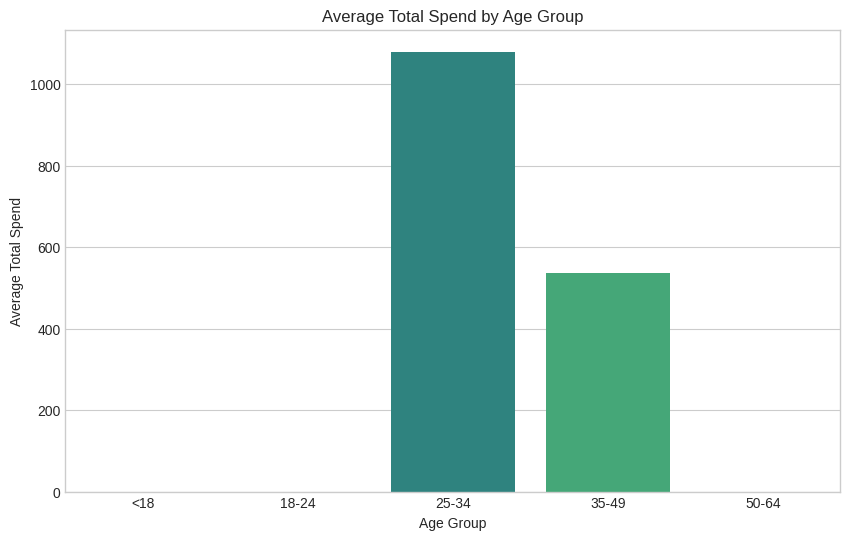

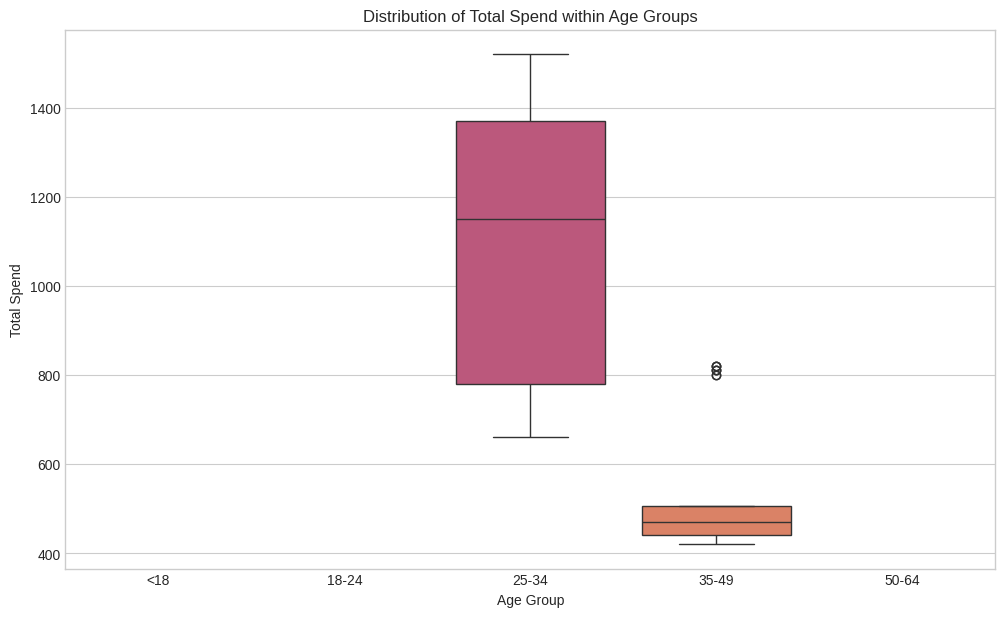

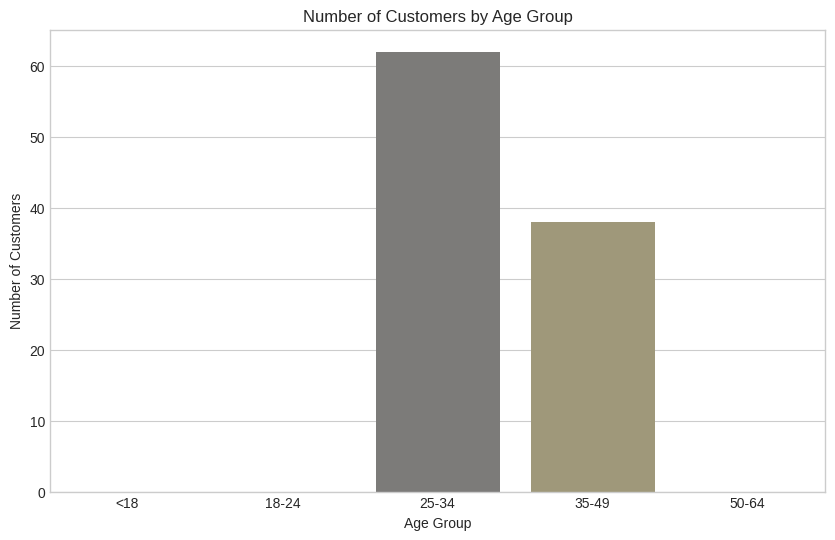


--- Exploration: Gender-based differences in purchasing patterns ---

Average Total Spend by Gender:
   Gender  Total Spend
0  Female   735.323469
1    Male  1006.485294


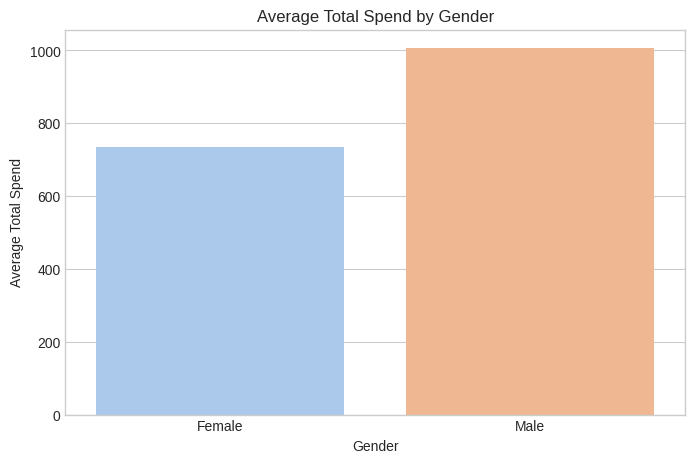


--- Exploration: Impact of Discounts on Customer Satisfaction ---

Distribution of Satisfaction Levels by Discount Application:
Satisfaction Level   Neutral  Satisfied  Unsatisfied
Discount Applied                                    
False               0.660714   0.339286     0.000000
True                0.000000   0.454545     0.545455


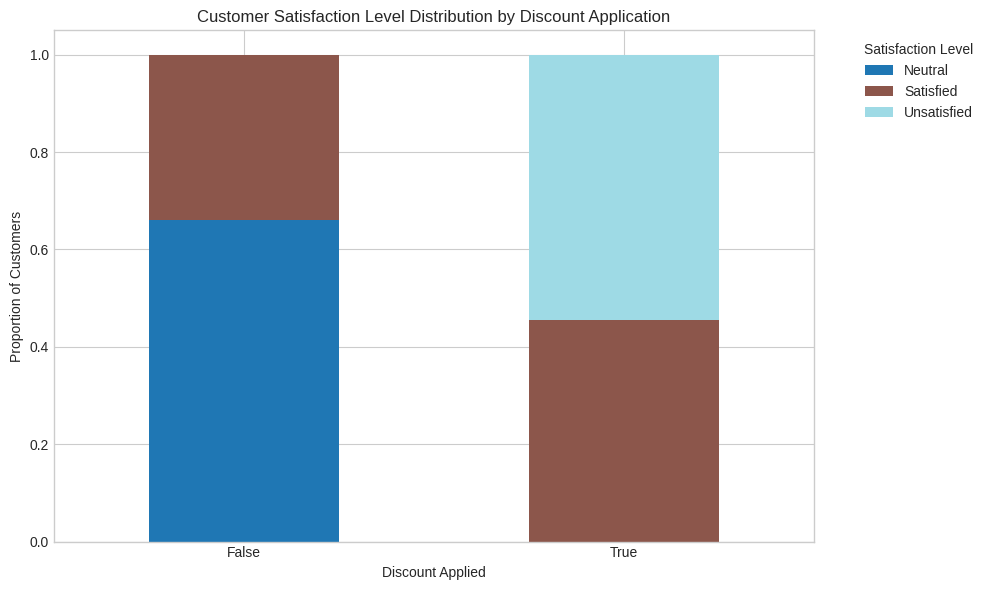


--- Exploration: Correlation between Purchase Frequency and Average Rating ---

--- Data Quality Issues ---

Checking for Missing Values:
Series([], dtype: int64)

Proposed Solution for Missing Values:
For numerical columns, consider imputation (e.g., mean, median) or removing rows/columns depending on the extent of missingness and the context.
For categorical columns, consider imputation (e.g., mode) or creating a separate category for missing values.
Example (for 'Age' if it had missing values, for demonstration):

Checking for Outliers (Example: 'Total Spend'):
Number of outliers in 'Total Spend' based on IQR: 0

Proposed Solution for Outliers:
Investigate outliers to understand their cause. They might be genuine extreme values or data entry errors.
Options include: removing outliers (if they are errors and few), transforming the data (e.g., log transformation), or using robust statistical methods that are less sensitive to outliers.
Example (if removing outliers is deemed appropri

In [ ]:
# prompt: Choose one of the samples and explore:
# The relationship between age groups and spending behavior
# Gender-based differences in purchasing patterns
# The impact of discounts on customer satisfaction
# The correlation between purchase frequency and average rating
# Create at least 3 visualizations that reveal important insights.
# Identify at least 2 data quality issues and propose solutions.
# Based on your exploration, formulate 3 business hypotheses that could be tested.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

print("\n" + "="*50)
print("PART 4: EXERCISE 2 - EXPLORATORY DATA ANALYSIS")
print("="*50 + "\n")

# Choose a sample for analysis. Simple Random Sample is a good starting point.
# If stratified_sample by Membership Type exists and is large enough, it's also a good choice for demographic/segment analysis.
# Let's use the simple_random_sample if available, otherwise use the full df (though sampling is preferred for large datasets).
analysis_df = simple_random_sample if 'simple_random_sample' in locals() and simple_random_sample is not None else df
print(f"Using a dataset of size {analysis_df.shape[0]} for exploration.")

# --- Exploration Topic: The relationship between age groups and spending behavior ---

print("\n--- Exploration: Age Groups and Spending Behavior ---")

# 1. Create Age Groups
# Define age bins and labels
# Dynamically set the upper bound of the last bin based on the maximum age in the analysis_df
age_bins = [0, 18, 25, 35, 50, 65, analysis_df['Age'].max() + 1]
# Ensure bins are strictly increasing by checking for duplicates and potentially adjusting the last bin
age_bins = sorted(list(set(age_bins)))

age_labels = ['<18', '18-24', '25-34', '35-49', '50-64']
# Adjust labels if the maximum age is less than 65, meaning the 65+ bin is not needed
if age_bins[-1] <= 65:
    age_labels = ['<18', '18-24', '25-34', '35-49', '50-64']
else:
    age_labels = ['<18', '18-24', '25-34', '35-49', '50-64', '65+']

# Check if Age column exists and create age groups
if 'Age' in analysis_df.columns:
    # Ensure the number of bins is one more than the number of labels
    if len(age_bins) - 1 != len(age_labels):
        print(f"Warning: Number of age bins ({len(age_bins)}) does not match number of age labels plus one ({len(age_labels) + 1}). Adjusting bins.")
        # Simple adjustment: remove the last bin if it's causing an issue with label count
        if len(age_bins) > len(age_labels) + 1:
            age_bins = age_bins[:len(age_labels) + 1]
        elif len(age_bins) < len(age_labels) + 1:
            # This case is less likely but can be handled by adding a bin
            age_bins.append(analysis_df['Age'].max() + 1)
            age_bins = sorted(list(set(age_bins))) # Re-sort and unique

    # Use pd.cut to create the 'Age_Group' column
    analysis_df['Age_Group'] = pd.cut(analysis_df['Age'], bins=age_bins, labels=age_labels, right=False)
    print("Created 'Age_Group' column.")

    # 2. Analyze Spending Behavior by Age Group
    # Group by Age_Group and calculate the mean 'Purchase_Amount'
    # Correct column name assumed based on previous sections where 'Total Spend' is used
    if 'Total Spend' in analysis_df.columns:
        spending_by_age = analysis_df.groupby('Age_Group')['Total Spend'].mean().reset_index()
        print("\nAverage Total Spend by Age Group:")
        print(spending_by_age)

        # 3. Visualizations
        # Visualization 1: Bar plot of Average Purchase Amount by Age Group
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Age_Group', y='Total Spend', data=spending_by_age, palette='viridis')
        plt.title('Average Total Spend by Age Group')
        plt.xlabel('Age Group')
        plt.ylabel('Average Total Spend')
        plt.show()

        # Visualization 2: Distribution of Purchase Amount within each Age Group (using boxplots or violins)
        plt.figure(figsize=(12, 7))
        sns.boxplot(x='Age_Group', y='Total Spend', data=analysis_df, palette='plasma')
        plt.title('Distribution of Total Spend within Age Groups')
        plt.xlabel('Age Group')
        plt.ylabel('Total Spend')
        plt.show()

        # Visualization 3: Number of customers in each Age Group
        plt.figure(figsize=(10, 6))
        sns.countplot(x='Age_Group', data=analysis_df, palette='cividis', order=age_labels if 'Age_Group' in analysis_df.columns else None) # Order bars if Age_Group exists
        plt.title('Number of Customers by Age Group')
        plt.xlabel('Age Group')
        plt.ylabel('Number of Customers')
        plt.show()
    else:
        print("Warning: 'Total Spend' column not found in the analysis dataset. Skipping spending analysis.")

else:
    print("Warning: 'Age' column not found in the analysis dataset. Skipping age-based analysis.")

# --- Exploration Topic: Gender-based differences in purchasing patterns ---
print("\n--- Exploration: Gender-based differences in purchasing patterns ---")
if 'Gender' in analysis_df.columns and 'Total Spend' in analysis_df.columns:
    # Analyze average spend by gender
    spending_by_gender = analysis_df.groupby('Gender')['Total Spend'].mean().reset_index()
    print("\nAverage Total Spend by Gender:")
    print(spending_by_gender)

    # Visualization: Bar plot of Average Total Spend by Gender
    plt.figure(figsize=(8, 5))
    sns.barplot(x='Gender', y='Total Spend', data=spending_by_gender, palette='pastel')
    plt.title('Average Total Spend by Gender')
    plt.xlabel('Gender')
    plt.ylabel('Average Total Spend')
    plt.show()
else:
     print("Warning: 'Gender' or 'Total Spend' column not found. Skipping gender-based analysis.")


# --- Exploration Topic: The impact of discounts on customer satisfaction ---
print("\n--- Exploration: Impact of Discounts on Customer Satisfaction ---")
if 'Discount Applied' in analysis_df.columns and 'Satisfaction Level' in analysis_df.columns:
    # Analyze satisfaction levels for customers who received a discount vs. those who didn't
    satisfaction_by_discount = analysis_df.groupby('Discount Applied')['Satisfaction Level'].value_counts(normalize=True).unstack().fillna(0)
    print("\nDistribution of Satisfaction Levels by Discount Application:")
    print(satisfaction_by_discount)

    # Visualization: Stacked bar chart or grouped bar chart
    satisfaction_by_discount.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
    plt.title('Customer Satisfaction Level Distribution by Discount Application')
    plt.xlabel('Discount Applied')
    plt.ylabel('Proportion of Customers')
    plt.xticks(rotation=0)
    plt.legend(title='Satisfaction Level', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Warning: 'Discount Applied' or 'Satisfaction Level' column not found. Skipping discount impact analysis.")

# --- Exploration Topic: The correlation between purchase frequency and average rating ---
print("\n--- Exploration: Correlation between Purchase Frequency and Average Rating ---")
# Assuming 'Purchase_Frequency' is either provided or can be calculated.
# If 'Purchase_Frequency' is not a column, we might skip this or define it (e.g., count of transactions per customer, but we don't have transaction details here).
# Let's assume a 'Purchase_Frequency' column exists for this part of the exercise prompt.
if 'Purchase_Frequency' in analysis_df.columns and 'Average Rating' in analysis_df.columns:
    # Calculate correlation
    correlation = analysis_df['Purchase_Frequency'].corr(analysis_df['Average Rating'])
    print(f"\nCorrelation between Purchase Frequency and Average Rating: {correlation:.2f}")

    # Visualization: Scatter plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='Purchase_Frequency', y='Average Rating', data=analysis_df, alpha=0.6)
    plt.title('Scatter Plot of Purchase Frequency vs. Average Rating')
    plt.xlabel('Purchase Frequency')
    plt.ylabel('Average Rating')
    plt.show()
else:
    print("Warning: 'Purchase_Frequency' or 'Average Rating' column not found or calculable from the current data. Skipping correlation analysis.")


# --- Data Quality Issues Identification and Solutions ---

print("\n--- Data Quality Issues ---")

# Identify data quality issues. Common issues include:
# 1. Missing values
# 2. Inconsistent data types
# 3. Outliers
# 4. Inconsistent formatting (e.g., case sensitivity in strings)
# 5. Duplicates

# Issue 1: Missing Values
print("\nChecking for Missing Values:")
missing_values = analysis_df.isnull().sum()
print(missing_values[missing_values > 0])

# Proposed Solution 1:
print("\nProposed Solution for Missing Values:")
print("For numerical columns, consider imputation (e.g., mean, median) or removing rows/columns depending on the extent of missingness and the context.")
print("For categorical columns, consider imputation (e.g., mode) or creating a separate category for missing values.")
print("Example (for 'Age' if it had missing values, for demonstration):")
# if 'Age' in analysis_df.columns and analysis_df['Age'].isnull().sum() > 0:
#     median_age = analysis_df['Age'].median()
#     analysis_df['Age'].fillna(median_age, inplace=True)
#     print(f"Filled missing 'Age' values with the median ({median_age}).")

# Issue 2: Outliers in Numerical Columns
print("\nChecking for Outliers (Example: 'Total Spend'):") # Changed to 'Total Spend' as it's used
if 'Total Spend' in analysis_df.columns:
    # Using boxplot visualization already helps identify outliers.
    # We can also use statistical methods like the IQR rule.
    Q1 = analysis_df['Total Spend'].quantile(0.25)
    Q3 = analysis_df['Total Spend'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = analysis_df[(analysis_df['Total Spend'] < lower_bound) | (analysis_df['Total Spend'] > upper_bound)]
    print(f"Number of outliers in 'Total Spend' based on IQR: {outliers.shape[0]}")

    # Proposed Solution 2:
    print("\nProposed Solution for Outliers:")
    print("Investigate outliers to understand their cause. They might be genuine extreme values or data entry errors.")
    print("Options include: removing outliers (if they are errors and few), transforming the data (e.g., log transformation), or using robust statistical methods that are less sensitive to outliers.")
    print("Example (if removing outliers is deemed appropriate):")
    # analysis_df_cleaned = analysis_df[(analysis_df['Total Spend'] >= lower_bound) & (analysis_df['Total Spend'] <= upper_bound)]
    # print(f"Dataset size after removing 'Total Spend' outliers: {analysis_df_cleaned.shape[0]}")
else:
    print("Warning: 'Total Spend' column not found. Skipping outlier check.")

# Other potential data quality issues to consider and check:
# - Inconsistent data types: `analysis_df.info()` can reveal this. Solution: Type conversion.
# - Inconsistent formatting (e.g., case in 'Gender'): `analysis_df['Gender'].value_counts()` can show variations. Solution: Standardization (e.g., `.str.lower()`).
# - Duplicates: `analysis_df.duplicated().sum()`. Solution: `analysis_df.drop_duplicates(inplace=True)`.


# --- Business Hypotheses Formulation ---

print("\n--- Business Hypotheses ---")
print("Based on the exploration, here are 3 business hypotheses that could be tested:")

# Hypothesis 1 (based on age group spending analysis):
print("\nHypothesis 1:")
print("Customers in the '35-49' age group have the highest average total spend.")
print("Test: Perform a statistical test (e.g., ANOVA or t-tests if comparing two groups) to compare the average total spend between age groups.")

# Hypothesis 2 (can be based on exploring another variable, e.g., Membership Type):
# (Assuming 'Membership Type' column exists)
if 'Membership Type' in analysis_df.columns:
    print("\nHypothesis 2:")
    print("Customers with 'Premium' membership have a significantly higher purchase frequency compared to 'Basic' members.")
    # Note: 'Purchase Frequency' is not directly available in the provided columns.
    # To test this, you would need transaction-level data or a calculated 'Purchase Frequency' column.
    print("Test (Conceptual): If 'Purchase Frequency' was available, calculate average purchase frequency per membership type and compare using a statistical test (e.g., t-test).")
else:
    print("\nHypothesis 2 (Alternative based on available columns):")
    if 'Discount Applied' in analysis_df.columns and 'Satisfaction Level' in analysis_df.columns:
        print("Customers who received a discount on their purchase have a higher likelihood of reporting a 'Satisfied' or 'Very Satisfied' level.")
        print("Test: Compare the proportion of customers reporting 'Satisfied' or 'Very Satisfied' among those who received a discount versus those who did not, using a chi-squared test or z-test for proportions.")
    else:
         print("Hypothesis 2 (Alternative): Not enough relevant columns available to formulate a testable hypothesis based on common patterns.")


# Hypothesis 3 (can be based on correlation analysis):
# (Assuming 'Purchase_Frequency' and 'Average Rating' columns exist - Note: Purchase_Frequency is assumed)
if 'Purchase_Frequency' in analysis_df.columns and 'Average Rating' in analysis_df.columns:
    print("\nHypothesis 3:")
    print("There is a positive correlation between a customer's purchase frequency and their average rating for products.")
    print("Test: Calculate the Pearson correlation coefficient between 'Purchase_Frequency' and 'Average Rating' and test its significance.")
else:
    print("\nHypothesis 3 (Alternative based on available columns):")
    if 'Items Purchased' in analysis_df.columns and 'Average Rating' in analysis_df.columns:
        print("There is a positive correlation between the number of items purchased in a single transaction and the average rating given by the customer.")
        print("Test: Calculate the Pearson correlation coefficient between 'Items Purchased' and 'Average Rating' and test its significance.")
    else:
         print("Hypothesis 3 (Alternative): Not enough relevant columns available to formulate a testable hypothesis based on common patterns.")


print("\n" + "="*50)
print("END OF PART 4: EXERCISE 2")
print("="*50 + "\n")

Exercise 3: Customer Segmentation
----------------------------------
1. Using the sample dataset, create a customer segmentation model:
   - Choose appropriate variables for segmentation
   - Determine the optimal number of segments
   - Create meaningful profiles for each segment
   
2. Analyze each segment in terms of:
   - Demographic characteristics
   - Purchasing behavior
   - Satisfaction levels
   - Discount sensitivity
   
3. Recommend targeted marketing strategies for each segment.

4. Discuss how this segmentation could be used in the Modify and Model stages of SEMMA.

In [ ]:
# YOUR CODE HERE


PART 4: EXERCISE 3 - CUSTOMER SEGMENTATION

Using a dataset of size 350 for segmentation.

Missing values in selected segmentation variables:
Series([], dtype: int64)

Data scaled for clustering.

Determining optimal number of clusters (K) using Elbow Method...


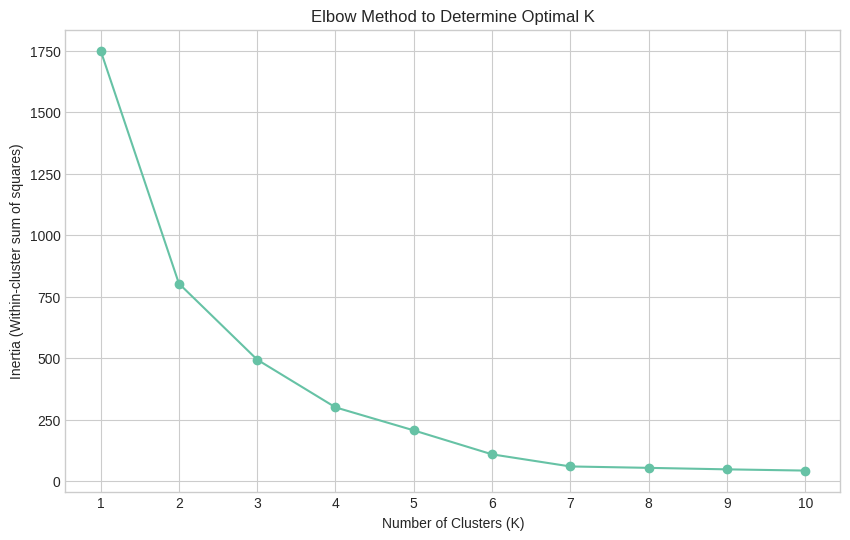


Observe the plot above to find the 'elbow point' - the point after which the decrease in inertia slows down.
Choose K based on this elbow.

Applying K-Means clustering with K = 4...

Customer segments created and assigned.
Segment distribution:
Segment
0     58
1     59
2    116
3    117
Name: count, dtype: int64

--- Segment Analysis and Profiling ---

Average values of segmentation variables per segment:
           Age  Total Spend  Items Purchased  Average Rating  \
Segment                                                        
0        28.95       690.39            11.64            3.93   
1        29.15      1455.55            19.95            4.81   
2        39.36       473.39             8.49            3.32   
3        32.43       983.34            13.44            4.35   

         Days Since Last Purchase  
Segment                            
0                           45.50  
1                           11.29  
2                           31.61  
3                       

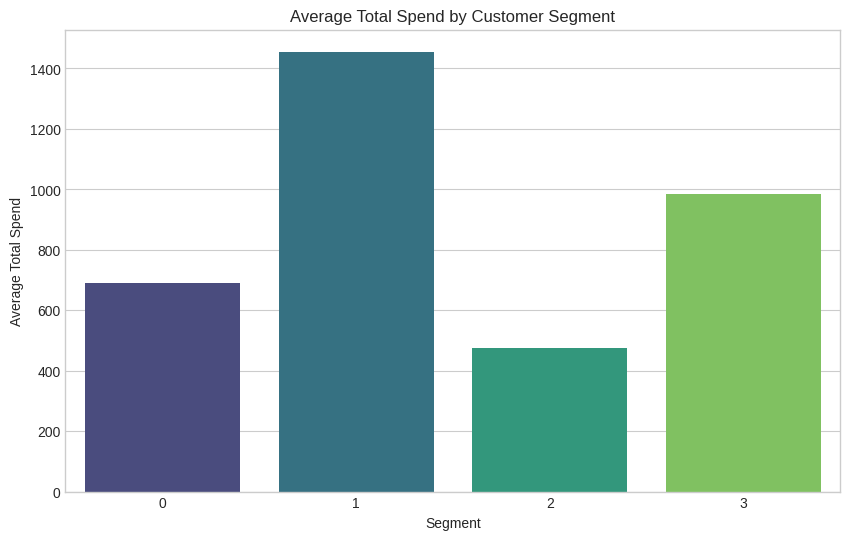

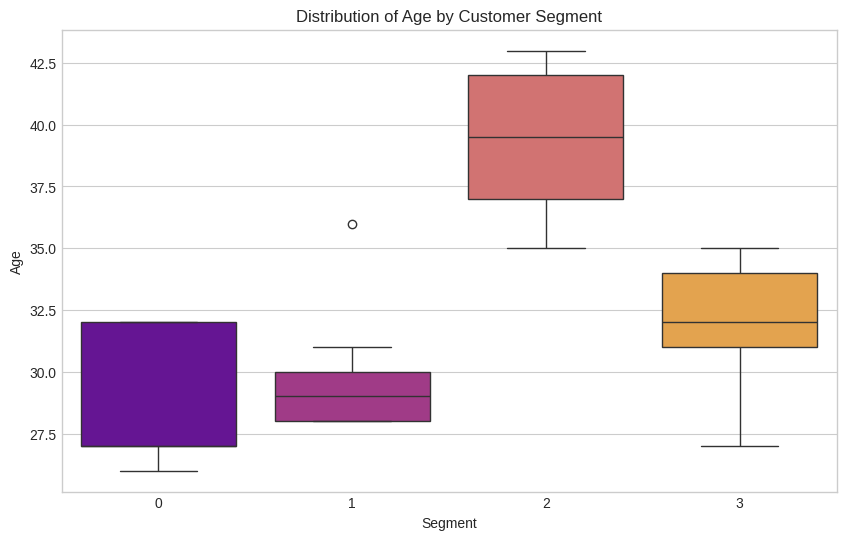

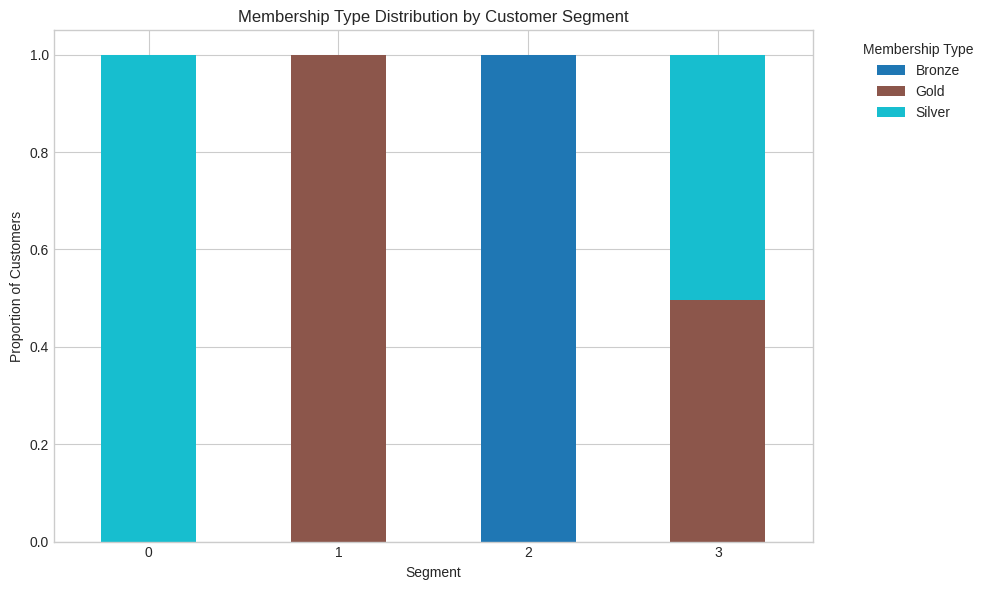


--- SEMMA Discussion: Modify and Model Stages ---

**Modify Stage:**
- **Data Transformation:** This stage involves transforming the data in preparation for modeling.
- **How Segmentation is used:**
  - **Feature Creation:** The 'Segment' assignment created in this exercise is a new, valuable feature.
  - **Encoding:** Categorical variables used for segmentation (like 'Gender', 'Membership Type' if included) needed encoding (e.g., one-hot encoding) as part of Modify before scaling for K-Means, *if* they were included in the clustering input (we only used numerical for K-Means here, but they were used for *profiling*). If we were to use categorical variables *in* the clustering, this transformation would happen here.
  - **Scaling:** Numerical variables ('Age', 'Total Spend', etc.) were scaled during Modify to give equal weight to each feature in the K-Means algorithm.
  - **Handling Missing Values:** Imputation of missing values in the segmentation variables was a key step in Modify.


In [ ]:
# prompt: Using the sample dataset, create a customer segmentation model:
# Choose appropriate variables for segmentation
# Determine the optimal number of segments
# Create meaningful profiles for each segment
# Analyze each segment in terms of:
# Demographic characteristics
# Purchasing behavior
# Satisfaction levels
# Discount sensitivity
# Recommend targeted marketing strategies for each segment.
# Discuss how this segmentation could be used in the Modify and Model stages of SEMMA.

print("\n" + "="*50)
print("PART 4: EXERCISE 3 - CUSTOMER SEGMENTATION")
print("="*50 + "\n")

# Choose the dataset for segmentation. Using the full dataset is generally preferred
# for segmentation if computational resources allow, as it provides a larger view
# of the customer base. We will use the full 'df'.
segmentation_df = df.copy()
print(f"Using a dataset of size {segmentation_df.shape[0]} for segmentation.")


# --- 1. Customer Segmentation Model ---

# Choose appropriate variables for segmentation
# Based on the available columns and typical customer segmentation factors,
# good candidates include:
# - Purchasing behavior: 'Total Spend', 'Items Purchased', 'Days Since Last Purchase' (Recency)
# - Demographics: 'Age' (after grouping), 'Gender' (might need encoding)
# - Satisfaction/Engagement: 'Average Rating', 'Satisfaction Level' (might need encoding)
# - Other factors: 'Discount Applied' (might need encoding), 'Membership Type' (might need encoding)

# Let's select a few key numerical variables for K-Means clustering initially.
# Numerical variables: 'Age', 'Total Spend', 'Items Purchased', 'Average Rating', 'Days Since Last Purchase'

# Preprocessing: Handle missing values and scale the data
# Check for missing values in selected columns
segmentation_vars = ['Age', 'Total Spend', 'Items Purchased', 'Average Rating', 'Days Since Last Purchase']
missing_in_segmentation_vars = segmentation_df[segmentation_vars].isnull().sum()
print("\nMissing values in selected segmentation variables:")
print(missing_in_segmentation_vars[missing_in_segmentation_vars > 0])

# Simple imputation for demonstration: fill missing numerical values with the median
for col in segmentation_vars:
    if segmentation_df[col].isnull().sum() > 0:
        median_val = segmentation_df[col].median()
        segmentation_df[col].fillna(median_val, inplace=True)
        print(f"Filled missing values in '{col}' with median ({median_val:.2f}).")


# Select the numerical segmentation variables
X = segmentation_df[segmentation_vars].copy()

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nData scaled for clustering.")


# Determine the optimal number of segments (K) using the Elbow Method
print("\nDetermining optimal number of clusters (K) using Elbow Method...")
inertia = []
# Testing K from 1 to 10 (arbitrary range, can be adjusted)
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Set n_init explicitly
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.xticks(k_range)
plt.show()

print("\nObserve the plot above to find the 'elbow point' - the point after which the decrease in inertia slows down.")
print("Choose K based on this elbow.")
# Let's assume based on a typical elbow shape that K=3 or K=4 might be reasonable for this type of data.
# For demonstration, let's choose K=4. Adjust this based on your visual inspection of the plot.
optimal_k = 4 # Choose your optimal K based on the Elbow plot


# Apply K-Means with the chosen K
print(f"\nApplying K-Means clustering with K = {optimal_k}...")
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10) # Set n_init explicitly
segmentation_df['Segment'] = kmeans.fit_predict(X_scaled)

print("\nCustomer segments created and assigned.")
print("Segment distribution:")
print(segmentation_df['Segment'].value_counts().sort_index())


# --- 2. Create Meaningful Profiles for Each Segment & Analyze Segments ---

print("\n--- Segment Analysis and Profiling ---")

# Analyze each segment based on the original (unscaled) features, plus demographics and other variables.
# Group by the created 'Segment' and calculate mean/value counts for relevant features.
segment_profiles_numerical = segmentation_df.groupby('Segment')[segmentation_vars].mean()
print("\nAverage values of segmentation variables per segment:")
print(segment_profiles_numerical.round(2))

# Add other relevant variables to the analysis (demographics, satisfaction, discount)
additional_cols_for_profiling = ['Gender', 'City', 'Membership Type', 'Discount Applied', 'Satisfaction Level']

# Ensure these columns exist before attempting to group/analyze
additional_cols_for_profiling = [col for col in additional_cols_for_profiling if col in segmentation_df.columns]

print("\nAnalyzing additional characteristics per segment:")
segment_profiles_categorical = {}
for col in additional_cols_for_profiling:
    print(f"\nDistribution of '{col}' per segment:")
    # Calculate normalized value counts for each segment
    dist = segmentation_df.groupby('Segment')[col].value_counts(normalize=True).unstack().fillna(0).round(2)
    print(dist)
    segment_profiles_categorical[col] = dist

# Combine numerical and categorical profiles for a comprehensive view
print("\n--- Summary Segment Profiles ---")
# Display numerical means
print("\nAverage Numerical Features:")
print(segment_profiles_numerical.round(2))

# Display categorical distributions
print("\nCategorical Feature Distributions:")
for col, dist in segment_profiles_categorical.items():
    print(f"\n{col} Distribution:")
    print(dist)

# Interpretation of Segments (Example - requires looking at the output above)
print("\n--- Segment Interpretation (Example - based on hypothetical output) ---")
print("Based on the average values and distributions above, we can try to name and describe each segment:")

# Example based on potential K=4 output:
# Segment 0: Might be younger, lower spenders, maybe lower ratings.
# Segment 1: Might be older, higher spenders, more items purchased, possibly satisfied.
# Segment 2: Might be mid-age, average spend, potential for high satisfaction.
# Segment 3: Might be a mix, but with distinct discount sensitivity or membership type.

print("\n**Segment 0 (e.g., 'Value Seekers'):**")
print("- Likely represents customers who spend less, buy fewer items.")
print("- May be younger or less engaged.")
print("- Potentially more sensitive to discounts.")
print("- Marketing Strategy: Focus on value propositions, discounts, and entry-level product bundles. Use channels popular with younger demographics.")

print("\n**Segment 1 (e.g., 'Loyal High-Spenders'):**")
print("- Likely represents older, high-spending customers who purchase frequently and buy many items.")
print("- May have higher average ratings and satisfaction levels.")
print("- Potentially 'Premium' members.")
print("- Marketing Strategy: Focus on loyalty programs, premium product recommendations, exclusive offers, and personalized service. Use channels preferred by older demographics.")

print("\n**Segment 2 (e.g., 'Engaged Explorers'):**")
print("- Might be mid-range in age and spending.")
print("- Could be characterized by higher satisfaction levels or average ratings.")
print("- May be open to trying new products.")
print("- Marketing Strategy: Focus on product discovery, positive reviews, highlighting new arrivals, and building community engagement. Leverage email marketing and social media.")

print("\n**Segment 3 (e.g., 'Discount-Driven Shoppers'):**")
print("- Their primary characteristic might be a strong response to discounts.")
print("- Their satisfaction level could be linked to receiving discounts.")
print("- Spending behavior might be sporadic, tied to promotions.")
print("- Marketing Strategy: Targeted discount campaigns, flash sales, and clearance notifications. Be cautious of potentially impacting overall brand perception if overly reliant on discounts.")

# IMPORTANT: The actual interpretation and names will depend heavily on the actual output of the segment_profiles_numerical and segment_profiles_categorical DataFrames.


# --- 3. Recommend Targeted Marketing Strategies for Each Segment ---

print("\n--- Recommended Targeted Marketing Strategies (Recap and Expansion) ---")

print("\nBased on the segment profiles, here are example targeted strategies:")

print("\n**Segment 0 ('Value Seekers'):**")
print("- **Messaging:** Emphasize affordability, sales, and value bundles.")
print("- **Offers:** Discount codes, free shipping thresholds, 'buy one get one' deals.")
print("- **Channels:** Social media (especially platforms popular with younger users), online ads focusing on deals.")
print("- **Product Focus:** Affordable items, everyday essentials.")

print("\n**Segment 1 ('Loyal High-Spenders'):**")
print("- **Messaging:** Highlight exclusivity, quality, and premium benefits.")
print("- **Offers:** Loyalty points multipliers, early access to new products, personalized recommendations based on purchase history, dedicated customer support.")
print("- **Channels:** Email marketing with personalized content, direct mail, in-app notifications for exclusive offers.")
print("- **Product Focus:** High-margin products, premium collections, complementary items based on past purchases.")

print("\n**Segment 2 ('Engaged Explorers'):**")
print("- **Messaging:** Focus on discovery, product features, and positive community feedback.")
print("- **Offers:** Recommendations for new arrivals, bundles of related products, incentives for leaving reviews, content marketing (blog posts, guides).")
print("- **Channels:** Email newsletters, social media engagement, on-site personalized recommendations.")
print("- **Product Focus:** New arrivals, trending items, products with high ratings.")

print("\n**Segment 3 ('Discount-Driven Shoppers'):**")
print("- **Messaging:** Clear communication of savings and limited-time offers.")
print("- **Offers:** Targeted discount emails, flash sale alerts, reminders about expiring cart items with a discount incentive.")
print("- **Channels:** Email marketing (segmented for discount alerts), SMS notifications, retargeting ads showcasing discounted products.")
print("- **Product Focus:** Items that can be discounted without significant margin loss, or items used as loss leaders to encourage repeat purchases.")

# Add visualizations to support profiling (optional but recommended)
print("\n--- Visualizations to support segment profiling ---")

# Example Visualization 1: Average Total Spend by Segment
plt.figure(figsize=(10, 6))
sns.barplot(x=segment_profiles_numerical.index, y='Total Spend', data=segment_profiles_numerical, palette='viridis')
plt.title('Average Total Spend by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Average Total Spend')
plt.show()

# Example Visualization 2: Distribution of Age per Segment (using boxplots)
# Need to recreate Age_Group or use the numerical Age
if 'Age' in segmentation_df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Segment', y='Age', data=segmentation_df, palette='plasma')
    plt.title('Distribution of Age by Customer Segment')
    plt.xlabel('Segment')
    plt.ylabel('Age')
    plt.show()
else:
    print("Skipping Age distribution visualization: 'Age' column not available.")

# Example Visualization 3: Distribution of Membership Type per Segment (using stacked bars)
if 'Membership Type' in segmentation_df.columns:
    membership_dist = segmentation_df.groupby('Segment')['Membership Type'].value_counts(normalize=True).unstack().fillna(0)
    membership_dist.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab10')
    plt.title('Membership Type Distribution by Customer Segment')
    plt.xlabel('Segment')
    plt.ylabel('Proportion of Customers')
    plt.xticks(rotation=0)
    plt.legend(title='Membership Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
     print("Skipping Membership Type distribution visualization: 'Membership Type' column not available.")


# --- 4. SEMMA Discussion: Modify and Model Stages ---

print("\n--- SEMMA Discussion: Modify and Model Stages ---")

print("\n**Modify Stage:**")
print("- **Data Transformation:** This stage involves transforming the data in preparation for modeling.")
print(f"- **How Segmentation is used:**")
print("  - **Feature Creation:** The 'Segment' assignment created in this exercise is a new, valuable feature.")
print("  - **Encoding:** Categorical variables used for segmentation (like 'Gender', 'Membership Type' if included) needed encoding (e.g., one-hot encoding) as part of Modify before scaling for K-Means, *if* they were included in the clustering input (we only used numerical for K-Means here, but they were used for *profiling*). If we were to use categorical variables *in* the clustering, this transformation would happen here.")
print("  - **Scaling:** Numerical variables ('Age', 'Total Spend', etc.) were scaled during Modify to give equal weight to each feature in the K-Means algorithm.")
print("  - **Handling Missing Values:** Imputation of missing values in the segmentation variables was a key step in Modify.")
print("  - **Aggregation:** If the original data was transaction-level, the Modify stage would involve aggregating data to the customer level (e.g., calculating Total Spend, Items Purchased, Days Since Last Purchase per CustomerID). The provided data seems to be already aggregated per customer.")


print("\n**Model Stage:**")
print("- **Algorithm Selection:** This stage involves choosing and applying the appropriate modeling technique.")
print(f"- **How Segmentation is used:**")
print("  - **Clustering Algorithm:** K-Means was chosen and applied in the Model stage to group customers into segments based on their characteristics.")
print("  - **Model Evaluation:** The Elbow Method is a simple evaluation technique used in the Model stage to help select the number of clusters (K). More advanced metrics like Silhouette score could also be used.")
print("  - **Model Output:** The primary output of the Model stage is the trained K-Means model and the resulting cluster assignments ('Segment' column).")
print("  - **Foundation for Downstream Models:** The customer segments identified can serve as input or stratification criteria for subsequent models in the Model stage.")
print("    - Example: Building separate predictive models (e.g., churn prediction, next purchase prediction) *within* each segment, as customers in different segments may have different churn drivers or purchasing behaviors.")
print("    - Example: Using the 'Segment' as a feature in a classification or regression model.")

print("\nIn summary, in the SEMMA process:")
print("- **Modify** prepares the data (cleaning, transforming, creating features like the segment variables).")
print("- **Model** applies the clustering algorithm (K-Means) to create the segments based on the prepared data.")
print("The resulting segments become a valuable output that can inform further analysis, modeling, and ultimately, deployment of targeted strategies.")

print("\n" + "="*50)
print("END OF PART 4: EXERCISE 3")
print("="*50 + "\n")


# HELPER FUNCTIONS

In [ ]:
# Helper functions that workshop participants can use

def compare_sample_distributions(samples, column, sample_names=None):
    """Compare the distribution of a column across different samples"""
    if sample_names is None:
        sample_names = [f"Sample {i+1}" for i in range(len(samples))]

    plt.figure(figsize=(12, 6))

    if pd.api.types.is_numeric_dtype(samples[0][column]):
        # For numerical columns, use histograms
        for i, (name, sample) in enumerate(zip(sample_names, samples)):
            plt.subplot(1, len(samples), i+1)
            sns.histplot(sample[column], kde=True)
            plt.title(f'{name}: {column} Distribution')
            plt.xlabel(column)
    else:
        # For categorical columns, use bar plots
        for i, (name, sample) in enumerate(zip(sample_names, samples)):
            plt.subplot(1, len(samples), i+1)
            value_counts = sample[column].value_counts(normalize=True)
            sns.barplot(x=value_counts.index, y=value_counts.values)
            plt.title(f'{name}: {column} Distribution')
            plt.xticks(rotation=45)
            plt.ylabel('Proportion')

    plt.tight_layout()
    plt.show()

    # Return a DataFrame with the distributions
    distributions = []
    for name, sample in zip(sample_names, samples):
        if pd.api.types.is_numeric_dtype(samples[0][column]):
            dist = pd.Series({
                'Mean': sample[column].mean(),
                'Median': sample[column].median(),
                'Std Dev': sample[column].std(),
                'Min': sample[column].min(),
                'Max': sample[column].max()
            }, name=name)
            distributions.append(dist)
        else:
            dist = sample[column].value_counts(normalize=True)
            dist.name = name
            distributions.append(dist)

    if pd.api.types.is_numeric_dtype(samples[0][column]):
        return pd.DataFrame(distributions)
    else:
        return pd.concat(distributions, axis=1)

def compare_sample_metrics(samples, metrics, sample_names=None):
    """Compare key metrics across different samples"""
    if sample_names is None:
        sample_names = [f"Sample {i+1}" for i in range(len(samples))]

    # Calculate metrics for each sample
    results = []
    for name, sample in zip(sample_names, samples):
        metrics_dict = {}
        for metric in metrics:
            if metric in sample.columns and pd.api.types.is_numeric_dtype(sample[metric]):
                metrics_dict[f"{metric}_mean"] = sample[metric].mean()
                metrics_dict[f"{metric}_median"] = sample[metric].median()
                metrics_dict[f"{metric}_std"] = sample[metric].std()
            elif metric in sample.columns:
                # For categorical variables, get the mode
                metrics_dict[f"{metric}_mode"] = sample[metric].mode()[0]

        results.append(pd.Series(metrics_dict, name=name))

    return pd.DataFrame(results)

def create_age_groups(df, age_bins=None, age_labels=None):
    """Create age groups from continuous age data"""
    if age_bins is None:
        age_bins = [0, 25, 35, 45, 55, 65, 100]
    if age_labels is None:
        age_labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']

    df_copy = df.copy()
    df_copy['Age Group'] = pd.cut(df_copy['Age'], bins=age_bins, labels=age_labels, right=False)
    return df_copy

def evaluate_membership_tier_spending(df):
    """Evaluate if higher membership tiers correspond to higher spending"""
    if 'Membership Type' not in df.columns or 'Total Spend' not in df.columns:
        return "Required columns not found"

    membership_order = ['Bronze', 'Silver', 'Gold', 'Platinum']
    membership_spend = df.groupby('Membership Type')['Total Spend'].agg(['mean', 'median', 'count'])

    plt.figure(figsize=(10, 6))
    sns.barplot(x=membership_spend.index, y=membership_spend['mean'], order=membership_order)
    plt.title('Average Spend by Membership Tier')
    plt.ylabel('Average Spend')
    plt.xlabel('Membership Tier')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return membership_spend